# Phase 2 from scratch — a quantum twin of TmMgGaO$_4$

## Purpose
We will make a neutral-atom simulator reproduce the field response of the frustrated triangular magnet TmMgGaO$_4$. All 49 atoms of a $7\times7$ triangular register are evolved, while observables are reported on the central $5\times5$ region, leaving one outer buffer layer to reduce boundary effects.

The two headline results follow Leclerc *et al.*:

1. quantum-twin magnetisation $M^z(\Delta_z/J_1)$;
2. connected 1/3 structure factor $S^{zz}(\mathbf q_{1/3},\Delta_z/J_1)$.

After validating those curves and MPS convergence, we estimate a finite-size critical field using the paper's maximum-slope, varying-fit-window method. This notebook creates its own fresh batch manifest and never reads previous Phase-2 results.

## 0. Imports and explicit configuration

`SUBMIT_NEW_JOBS` is a safety switch. Keep it `False` while inspecting the notebook. Change it to `True` exactly once to submit the fresh jobs, wait for all batches to finish, then change it back to `False` before rerunning. Batch IDs are stored in `phase2_from_scratch_batches.json`.

In [ ]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml
import pulser
from pulser import Register, Sequence
from pulser.backend import BitStrings
from pulser.devices import MockDevice
from pulser.pulse import Pulse
from pulser.waveforms import ConstantWaveform, RampWaveform
from pulser_pasqal import PasqalCloud
from pasqal_cloud import SDK

L=7
N=L*L
SHOTS=1000
DT_NS=10
CHI_MAIN=50
CHI_CHECK=100
OMEGA_OVER_2PI_MHZ=2.0
TARGET_DX_OVER_J1=1.08
FIELDS=np.array([1.,2.,2.5,2.75,3.,3.25,3.5,3.625,3.75,3.875,4.,4.125,4.25,4.375,4.5,4.625,4.875,5.,5.125,5.25,5.375,5.5,5.625,5.875,6.,8.,10.])
CHECK_FIELDS=np.array([3.5,4.0,4.5,5.0])
CREDENTIALS_FILE='credentials.example.yaml'
BATCH_FILE=Path('phase2_paper_pulse_batches.json')
SUBMIT_NEW_JOBS=False
print('Pulser',pulser.__version__,'| fields',len(FIELDS))

Pulser 1.8.0 | fields 22


## 1. Material Hamiltonian

The thulium magnetic moments are represented as pseudospin-$1/2$ variables on a triangular lattice:
$$\frac{H_{\rm mat}}{\hbar}=J_1\sum_{\langle i,j\rangle}\sigma_i^z\sigma_j^z+J_2\sum_{\langle\langle i,j\rangle\rangle}\sigma_i^z\sigma_j^z+\sum_i(\Delta_x\sigma_i^x-\Delta_z\sigma_i^z).$$

- $J_1>0$: nearest neighbours prefer opposite $z$ spins. On triangles this cannot be satisfied on every bond, creating geometrical frustration.
- $J_2/J_1\simeq0.05$: weaker next-neighbour interaction.
- $\Delta_x/J_1\simeq1.08$: intrinsic transverse field, producing quantum superpositions and spin flips.
- $\Delta_z/J_1$: longitudinal material field scanned on our horizontal axis. High field favours $\sigma^z=+1$ and polarises the material.

## 2. Rydberg Hamiltonian and complete mapping derivation

Pulser implements, in angular-frequency units $u_{ij}=U_{ij}/\hbar$,
$$\frac{H_{\rm QPU}}{\hbar}=\sum_{i<j}u_{ij}n_in_j+\frac{\Omega}{2}\sum_i\sigma_i^x-\delta\sum_i n_i,$$
where $n_i=0$ for $|g\rangle$, $n_i=1$ for $|r\rangle$, and
$$n_i=\frac{1-\sigma_i^z}{2}.$$
Expand one interaction term:
$$u_{ij}n_in_j=\frac{u_{ij}}4(1-\sigma_i^z-\sigma_j^z+\sigma_i^z\sigma_j^z).$$
The final term is the desired Ising interaction, so for nearest neighbours
$$J_1=\frac{u_1}{4}.$$
The transverse terms match when
$$\Delta_x=\frac{\Omega}{2},\qquad \frac{\Delta_x}{J_1}=\frac{2\Omega}{u_1}.$$
Therefore $\Delta_x/J_1=1.08$ requires
$$\boxed{\Omega/u_1=0.54}.$$
The interaction expansion also produces single-site $-u_{ij}\sigma_i^z/4$ terms. Combining them with $-\delta n_i=-\delta/2+(\delta/2)\sigma_i^z$ gives a shifted longitudinal field. Define the array-average offset
$$\delta_U=\frac1N\sum_{i<j}u_{ij}=\frac1{2N}\sum_{i,j}u_{ij}.$$
Then
$$\Delta_z=\frac{\delta_U-\delta}{2},\qquad \boxed{\frac{\Delta_z}{J_1}=\frac{2(\delta_U-\delta)}{u_1}}.$$
The inverse control map is
$$\boxed{\delta_{\rm target}=\delta_U-\frac12(\Delta_z/J_1)u_1}.$$
The offset is actually site-dependent near open boundaries. We use the paper's global average for the programmed detuning and later measure a buffered central bulk.

## 3. Construct the triangular register and interaction shells

Triangular basis vectors are $\mathbf e_1=a(1,0)$ and $\mathbf e_2=a(1/2,\sqrt3/2)$, so $\mathbf r_{ij}=i\mathbf e_1+j\mathbf e_2$. We preserve the paper-like $\Omega/2\pi=2$ MHz and choose $a$ so that $u_1=\Omega/0.54$. `MockDevice` then gives a spacing different from the physical paper device, but the dimensionless Hamiltonian ratios are correct. Since $u(r)\propto r^{-6}$, the next triangular shell at $r=\sqrt3a$ has $u_2/u_1=1/27\simeq0.037$, close to $J_2/J_1\simeq0.05$.

In [ ]:
omega=2*np.pi*OMEGA_OVER_2PI_MHZ
u1=omega/(TARGET_DX_OVER_J1/2)
spacing=MockDevice.rydberg_blockade_radius(u1)
e1=spacing*np.array([1.,0.]);e2=spacing*np.array([.5,np.sqrt(3)/2])
ij=np.array([(i,j) for i in range(L) for j in range(L)])
xy=np.array([i*e1+j*e2 for i,j in ij])
register=Register.from_coordinates(xy,prefix='q')
r=np.linalg.norm(xy[:,None,:]-xy[None,:,:],axis=-1)
u=np.zeros_like(r);mask=r>0;u[mask]=MockDevice.interaction_coeff/r[mask]**6
delta_u=np.triu(u,1).sum()/N
local_delta_u=.5*u.sum(axis=1)
pair_r=r[np.triu_indices(N,1)]/spacing;pair_u=u[np.triu_indices(N,1)]/u1
print(f'spacing={spacing:.3f} µm, u1/2π={u1/(2*np.pi):.3f} MHz')
print(f'Omega/u1={omega/u1:.3f}, Delta_x/J1={2*omega/u1:.3f}')
print(f'global delta_U/u1={delta_u/u1:.3f}')
for shell in [1.,np.sqrt(3),2.,np.sqrt(7)]:
    m=np.isclose(pair_r,shell,rtol=1e-5)
    print(f'r/a={shell:.6f}: U/U1={pair_u[m].mean():.6f}, pairs={m.sum()}')
assert np.isclose(2*omega/u1,1.08)
assert np.isclose(pair_u[np.isclose(pair_r,np.sqrt(3),rtol=1e-5)].mean(),1/27,rtol=1e-4)

spacing=7.844 µm, u1/2π=3.704 MHz
Omega/u1=0.540, Delta_x/J1=1.080
global delta_U/u1=2.565
r/a=1.000000: U/U1=1.000000, pairs=120
r/a=1.732051: U/U1=0.037037, pairs=96
r/a=2.000000: U/U1=0.015625, pairs=95
r/a=2.645751: U/U1=0.002915, pairs=148


## 4. Full array versus measured bulk

All 49 atoms are evolved and interact. We report observables on sites with $1\le i,j\le5$, the central $5\times5$ region. The 24 grey atoms remain physically active as a one-row outer buffer. The three colours show the $A,B,C$ sublattices of the 1/3 pattern. Because 25 is not divisible by three, their populations are 9, 8, and 8; the complex-phase structure-factor formula handles this finite-size imbalance directly. This is a deliberate larger-bulk choice rather than the paper's stricter two-layer-buffer convention.

bulk indices [ 8  9 10 11 12 15 16 17 18 19 22 23 24 25 26 29 30 31 32 33 36 37 38 39
 40]
mean bulk delta_U/u1 3.1469788884490235 | global 2.5651197360663702


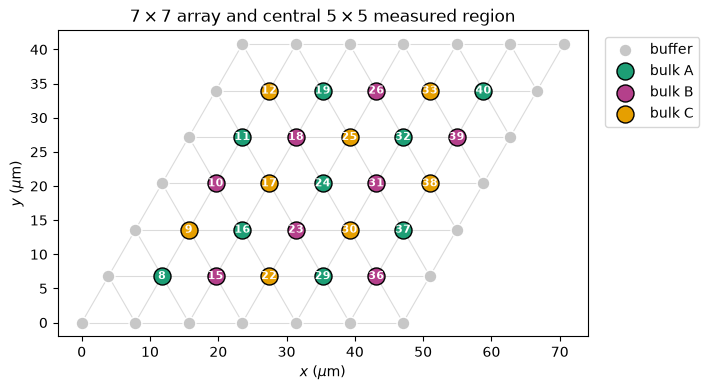

In [ ]:
bulk_mask=(ij[:,0]>=1)&(ij[:,0]<=5)&(ij[:,1]>=1)&(ij[:,1]<=5)
bulk_indices=np.flatnonzero(bulk_mask);Nb=len(bulk_indices)
bulk_ij=ij[bulk_indices];bulk_colours=(bulk_ij[:,0]-bulk_ij[:,1])%3
all_colours=(ij[:,0]-ij[:,1])%3
assert Nb==25 and np.array_equal(np.sort(np.bincount(bulk_colours,minlength=3)),[8,8,9])
palette=np.array(['#1D9E75','#B4408B','#E69F00'])
fig,ax=plt.subplots(figsize=(7.2,6.2))
for i in range(N):
    for j in range(i+1,N):
        if np.isclose(r[i,j],spacing,rtol=1e-6): ax.plot(xy[[i,j],0],xy[[i,j],1],color='.86',lw=.8,zorder=0)
ax.scatter(xy[~bulk_mask,0],xy[~bulk_mask,1],s=85,color='.78',edgecolor='white',label='buffer',zorder=2)
for colour,label in enumerate('ABC'):
    m=bulk_mask&(all_colours==colour)
    ax.scatter(xy[m,0],xy[m,1],s=150,color=palette[colour],edgecolor='black',label=f'bulk {label}',zorder=3)
for index in bulk_indices: ax.text(*xy[index],str(index),ha='center',va='center',fontsize=8,color='white',fontweight='bold',zorder=4) # type: ignore
ax.set_aspect('equal');ax.set_xlabel(r'$x$ ($\mu$m)');ax.set_ylabel(r'$y$ ($\mu$m)')
ax.set_title(r'$7\times7$ array and central $5\times5$ measured region');ax.legend(bbox_to_anchor=(1.02,1));fig.tight_layout()
print('bulk indices',bulk_indices)
print('mean bulk delta_U/u1',local_delta_u[bulk_indices].mean()/u1,'| global',delta_u/u1)

## 5. Pulse construction and visualisation

Each material field gets an independent paper-inspired preparation. We begin at $\delta_i=-3u_1$, equivalent to a very high material field and an easy all-$|g\rangle$ state. The supplement specifies a quasi-adiabatic timescale $T\sim5\,\mu$s followed by an $\Omega$ ramp-down as fast as possible; it does not publish every waveform knot. We therefore use a documented approximation with a 5-$\mu$s preparation plus a 100-ns AOM-like freeze.

1. **Turn on quantum fluctuations (0–1 $\mu$s):** ramp $\Omega:0\to0.54u_1$ at fixed $\delta_i$.
2. **Quasi-adiabatic field sweep (1–5 $\mu$s):** hold $\Omega$ and ramp $\delta_i\to\delta_{\rm target}$ over 4 $\mu$s. Together with stage 1, the preparation lasts 5 $\mu$s. Because $\Delta_z/J_1=2(\delta_U-\delta)/u_1$, a linear detuning ramp is a linear material-field ramp in the opposite direction.
3. **Fast freeze and measure (5–5.1 $\mu$s):** hold target detuning and ramp $\Omega\to0$ in 100 ns, approximating the supplementary note's AOM rise/fall scale and suppressing further coherent spin flips before bitstring sampling. The FM1 EOM implementation could be as fast as about 20 ns, which can later be tested as a robustness variation.

The representative plot uses $\Delta_z/J_1=4$; scan points share the same pulse shape and differ only in final detuning.

initial field 11.13023947213274 target detuning/u1 0.56511973606637


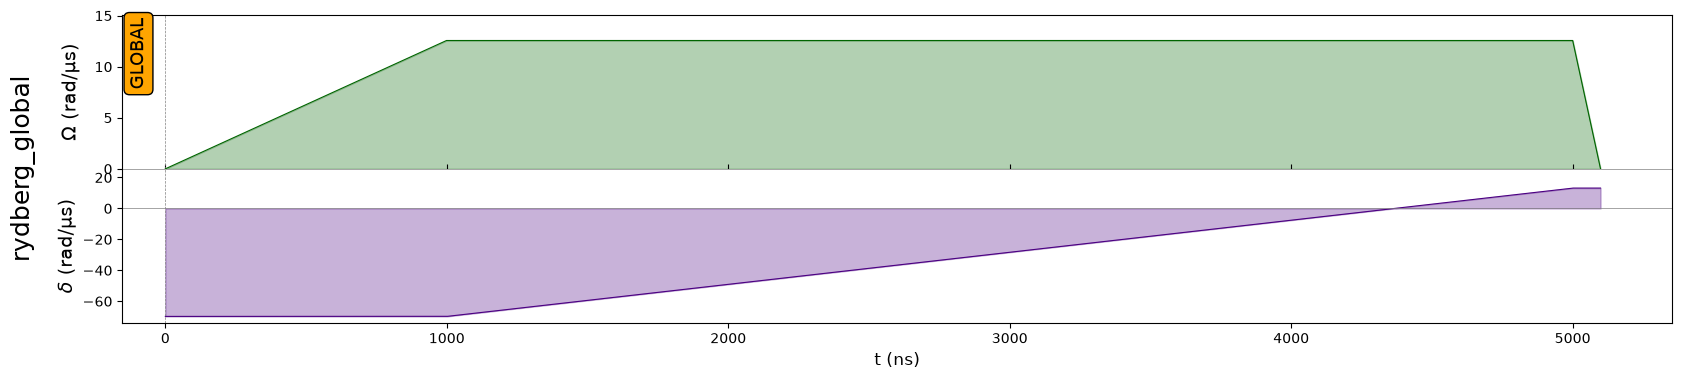

In [88]:
def material_to_detuning(field): return delta_u-.5*field*u1
def detuning_to_material(delta): return 2*(delta_u-delta)/u1
def build_sequence(field):
    di=-3*u1;df=material_to_detuning(field)
    seq=Sequence(register,MockDevice);seq.declare_channel('rydberg_global','rydberg_global')
    seq.add(Pulse(RampWaveform(1000,0,omega),ConstantWaveform(1000,di),0),'rydberg_global')
    seq.add(Pulse(ConstantWaveform(4000,omega),RampWaveform(4000,di,df),0),'rydberg_global')
    seq.add(Pulse(RampWaveform(100,omega,0),ConstantWaveform(100,df),0),'rydberg_global')
    return seq
test_fields=np.array([1.,4.,10.]);assert np.allclose([detuning_to_material(material_to_detuning(x)) for x in test_fields],test_fields)
representative=4.;print('initial field',detuning_to_material(-3*u1),'target detuning/u1',material_to_detuning(representative)/u1)
build_sequence(representative).draw()

## 6. Fresh Pasqal EmuMPS submission with persistent IDs

A full 49-qubit state has $2^{49}$ amplitudes, so we use a matrix product state (MPS). Bond dimension $\chi$ limits retained entanglement: larger $\chi$ is more expressive and more expensive. The main scan uses $\chi=50$; selected transition points use $100$. The numerical time step is $dt=10$ ns.

Run the next cell with `SUBMIT_NEW_JOBS=True` exactly once. It refuses to overwrite an existing manifest.

In [ ]:
SUBMIT_NEW_JOBS=False

def cloud_connection():
    c=yaml.safe_load(Path(CREDENTIALS_FILE).read_text())
    return PasqalCloud(username=c['username'],project_id=c['project_id'],password=c['password'])
def submit_one(connection,field,chi):
    cfg=pulser.backend.EmulationConfig(observables=(BitStrings(evaluation_times=[1.0],num_shots=SHOTS),),dt=DT_NS,max_bond_dim=chi)
    return pulser.backends.EmuMPSBackend(build_sequence(field),config=cfg,connection=connection).run().batch_id
if SUBMIT_NEW_JOBS:
    if BATCH_FILE.exists(): raise FileExistsError(f'{BATCH_FILE} exists; refusing duplicate submission.')
    connection=cloud_connection()
    batches={'metadata':{'L':L,'shots':SHOTS,'dt_ns':DT_NS,'chi_main':CHI_MAIN,'chi_check':CHI_CHECK},'chi50':{},'chi100':{}}
    for field in FIELDS:
        bid=submit_one(connection,float(field),CHI_MAIN);batches['chi50'][str(float(field))]=bid;print('chi50',field,bid)
    for field in CHECK_FIELDS:
        bid=submit_one(connection,float(field),CHI_CHECK);batches['chi100'][str(float(field))]=bid;print('chi100',field,bid)
    BATCH_FILE.write_text(json.dumps(batches,indent=2));print('saved',BATCH_FILE)
else:
    print('Submission disabled. Inspect first; set SUBMIT_NEW_JOBS=True once when ready.')

Submission disabled. Inspect first; set SUBMIT_NEW_JOBS=True once when ready.


## 7. Retrieve completed jobs

After submission, wait until the Pasqal dashboard shows `DONE`, set `SUBMIT_NEW_JOBS=False`, and run below. The status guard prevents incomplete jobs from becoming data.

In [90]:
if not BATCH_FILE.exists(): raise FileNotFoundError('Submit fresh jobs first.')
saved=json.loads(BATCH_FILE.read_text());cred=yaml.safe_load(Path(CREDENTIALS_FILE).read_text())
sdk=SDK(username=cred['username'],project_id=cred['project_id'],password=cred['password'])
def retrieve(group):
    out={}
    for field,bid in saved[group].items():
        batch=sdk.get_batch(bid);status=str(batch.status);print(group,field,status)
        if status!='DONE': raise RuntimeError(f'{bid} is {status}; wait and rerun.')
        result=batch.ordered_jobs[0].result
        if not isinstance(result,dict): raise TypeError(type(result))
        out[float(field)]=result
    return out
counts50=retrieve('chi50');counts100=retrieve('chi100')

chi50 1.0 DONE
chi50 2.0 DONE
chi50 2.5 DONE
chi50 3.0 DONE
chi50 3.25 DONE
chi50 3.5 DONE
chi50 3.625 DONE
chi50 3.75 DONE
chi50 3.875 DONE
chi50 4.0 DONE
chi50 4.125 DONE
chi50 4.25 DONE
chi50 4.375 DONE
chi50 4.5 DONE
chi50 4.625 DONE
chi50 4.75 DONE
chi50 5.0 DONE
chi50 5.25 DONE
chi50 5.5 DONE
chi50 6.0 DONE
chi50 8.0 DONE
chi50 10.0 DONE
chi100 3.5 DONE
chi100 4.0 DONE
chi100 4.5 DONE
chi100 5.0 DONE


## 8. Derive the paper-aligned observables

For each bulk bit, $z_i=1-2n_i$. Magnetisation is
$$M^z=\frac1{N_b}\sum_{i\in b}\langle z_i\rangle.$$
The paper uses connected correlations
$$C^{zz}_{ij}=\langle z_i z_j\rangle-\langle z_i\rangle\langle z_j\rangle.$$
Its ordering wavevector is $\mathbf q_{1/3}=\frac{2\pi}{3a}(1,\sqrt3)$. For $\mathbf r_{ij}=i\mathbf e_1+j\mathbf e_2$,
$$\mathbf q_{1/3}\cdot\mathbf r_{ij}=\frac{2\pi}{3}(i+2j),$$
which is equivalent modulo three to the colour $c=(i-j)\bmod3$. Thus $\phi_i=e^{2\pi i c_i/3}$ and
$$\boxed{S^{zz}(\mathbf q_{1/3})=\frac1{N_b}\boldsymbol\phi^\dagger C^{zz}\boldsymbol\phi}.$$
Unlike the earlier $S_3$, this subtracts the local mean and uses the paper's $1/N_b$ normalization. Bootstrap resampling recomputes the nonlinear connected covariance and supplies shot-sampling intervals.

In [91]:
phase=np.exp(2j*np.pi*bulk_colours/3);rng=np.random.default_rng(20260711)
def expand(counts):
    rows=[]
    for b,m in counts.items():
        row=np.fromiter((int(x) for x in b),dtype=np.int8)
        if len(row)!=N: raise ValueError(len(row))
        rows.extend([row]*m)
    return np.asarray(rows,float)[:,bulk_indices]
def estimate(z,index):
    x=z[index];mean=x.mean(axis=0);C=x.T@x/len(x)-np.outer(mean,mean)
    return np.array([x.mean(),float(np.real(np.conjugate(phase)@C@phase)/Nb)])
def summarize(counts,nboot=500):
    z=1-2*expand(counts);center=estimate(z,np.arange(len(z)));boot=np.empty((nboot,2))
    for b in range(nboot): boot[b]=estimate(z,rng.integers(0,len(z),len(z)))
    lo,hi=np.quantile(boot,[.16,.84],axis=0);return {'center':center,'low':lo,'high':hi,'z':z}
# Known-answer checks.
ground='0'*N;g=summarize({ground:20},20);assert np.isclose(g['center'][0],1) and np.isclose(g['center'][1],0)
summary50={f:summarize(c) for f,c in sorted(counts50.items())};summary100={f:summarize(c) for f,c in sorted(counts100.items())}
for f,s in summary50.items(): print(f'{f:4.2f}  Mz={s["center"][0]:+.3f}  Szz={s["center"][1]:.3f}')

1.00  Mz=+0.365  Szz=5.521
2.00  Mz=+0.476  Szz=2.792
2.50  Mz=+0.532  Szz=2.043
3.00  Mz=+0.579  Szz=1.686
3.25  Mz=+0.595  Szz=1.604
3.50  Mz=+0.613  Szz=1.417
3.62  Mz=+0.624  Szz=1.274
3.75  Mz=+0.636  Szz=1.159
3.88  Mz=+0.653  Szz=1.136
4.00  Mz=+0.666  Szz=1.013
4.12  Mz=+0.675  Szz=0.870
4.25  Mz=+0.684  Szz=0.850
4.38  Mz=+0.708  Szz=0.722
4.50  Mz=+0.723  Szz=0.679
4.62  Mz=+0.733  Szz=0.713
4.75  Mz=+0.715  Szz=0.721
5.00  Mz=+0.792  Szz=0.463
5.25  Mz=+0.760  Szz=0.615
5.50  Mz=+0.839  Szz=0.345
6.00  Mz=+0.897  Szz=0.192
8.00  Mz=+0.985  Szz=0.029
10.00  Mz=+1.000  Szz=0.000


## 9. Plot 1 — quantum-twin magnetisation

Every vertical error bar is the 16th–84th percentile interval from bootstrap resampling the EmuMPS bitstrings (an approximate 68% finite-shot interval). It quantifies sampling uncertainty only. The $\chi=50$ circles form the main scan; the $\chi=100$ diamonds are convergence checks and receive their own independently bootstrapped error bars. The programmed field values are treated as exact, so no horizontal error bars are drawn.

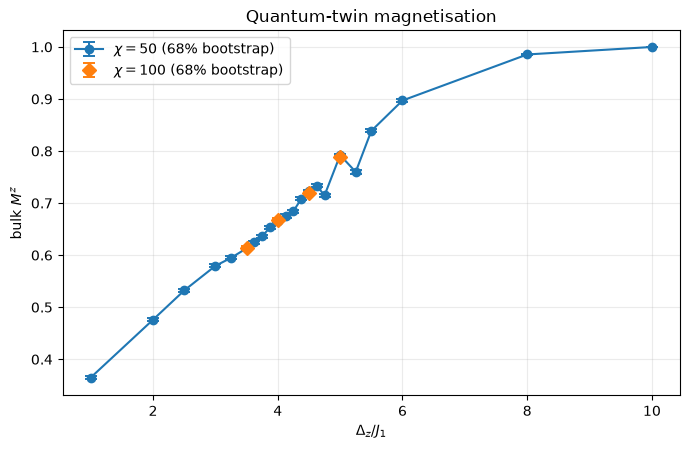

In [92]:
fields=np.array(sorted(summary50));check=np.array(sorted(summary100))
mz=np.array([summary50[f]['center'][0] for f in fields])
mzerr=np.array([[summary50[f]['center'][0]-summary50[f]['low'][0] for f in fields],[summary50[f]['high'][0]-summary50[f]['center'][0] for f in fields]])
mz100=np.array([summary100[f]['center'][0] for f in check])
mzerr100=np.array([[summary100[f]['center'][0]-summary100[f]['low'][0] for f in check],[summary100[f]['high'][0]-summary100[f]['center'][0] for f in check]])
fig,ax=plt.subplots(figsize=(7,4.6))
ax.errorbar(fields,mz,yerr=mzerr,fmt='o-',capsize=4,capthick=1.4,elinewidth=1.4,label=r'$\chi=50$ (68% bootstrap)')
ax.errorbar(check,mz100,yerr=mzerr100,fmt='D',ms=7,capsize=4,capthick=1.4,elinewidth=1.4,label=r'$\chi=100$ (68% bootstrap)')
ax.set(xlabel=r'$\Delta_z/J_1$',ylabel=r'bulk $M^z$',title='Quantum-twin magnetisation');ax.grid(alpha=.25);ax.legend();fig.tight_layout()

## 10. Plot 2 — connected 1/3 structure factor

The connected structure factor is nonlinear because it subtracts $\langle z_i\rangle\langle z_j\rangle$. Each bootstrap replicate therefore resamples complete shots and recomputes the site means, correlation matrix, and structure factor together. The displayed 16th–84th percentile bars preserve correlations between atoms and again represent finite-shot uncertainty, not finite-size, pulse-calibration, or MPS-model error.

max chi difference Mz 0.0042400000000000215
max chi difference Szz 0.03406240000000027


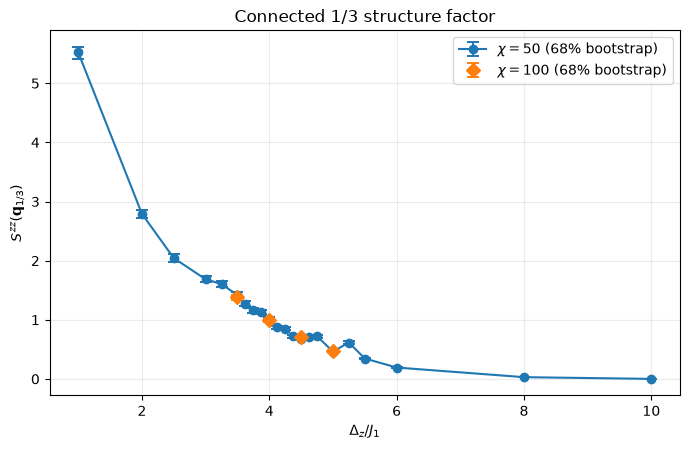

In [93]:
szz=np.array([summary50[f]['center'][1] for f in fields])
szzerr=np.array([[summary50[f]['center'][1]-summary50[f]['low'][1] for f in fields],[summary50[f]['high'][1]-summary50[f]['center'][1] for f in fields]])
szz100=np.array([summary100[f]['center'][1] for f in check])
szzerr100=np.array([[summary100[f]['center'][1]-summary100[f]['low'][1] for f in check],[summary100[f]['high'][1]-summary100[f]['center'][1] for f in check]])
fig,ax=plt.subplots(figsize=(7,4.6))
ax.errorbar(fields,szz,yerr=szzerr,fmt='o-',capsize=4,capthick=1.4,elinewidth=1.4,label=r'$\chi=50$ (68% bootstrap)')
ax.errorbar(check,szz100,yerr=szzerr100,fmt='D',ms=7,capsize=4,capthick=1.4,elinewidth=1.4,label=r'$\chi=100$ (68% bootstrap)')
ax.set(xlabel=r'$\Delta_z/J_1$',ylabel=r'$S^{zz}(\mathbf{q}_{1/3})$',title='Connected 1/3 structure factor');ax.grid(alpha=.25);ax.legend();fig.tight_layout()
print('max chi difference Mz',max(abs(summary100[f]['center'][0]-summary50[f]['center'][0]) for f in check))
print('max chi difference Szz',max(abs(summary100[f]['center'][1]-summary50[f]['center'][1]) for f in check))

## 11. Paper-style finite-size critical-point extraction

A finite system has a rounded crossover, so we estimate a pseudo-critical field where the smooth structure-factor curve falls most rapidly. The paper fits cubics over several overlapping windows, differentiates each fit, and varies the window to quantify fit sensitivity. We reject fits whose derivative extremum lies at a window boundary; that signals insufficient scan coverage. Point error bars remain the 68% finite-shot bootstrap intervals. The shaded vertical band is different: it spans the 16th–84th percentiles of the accepted critical estimates obtained by varying the cubic fit window. The $\chi=50/100$ comparison remains a separate MPS-truncation diagnostic.

window-variation estimate: 3.676 +0.053 -0.053


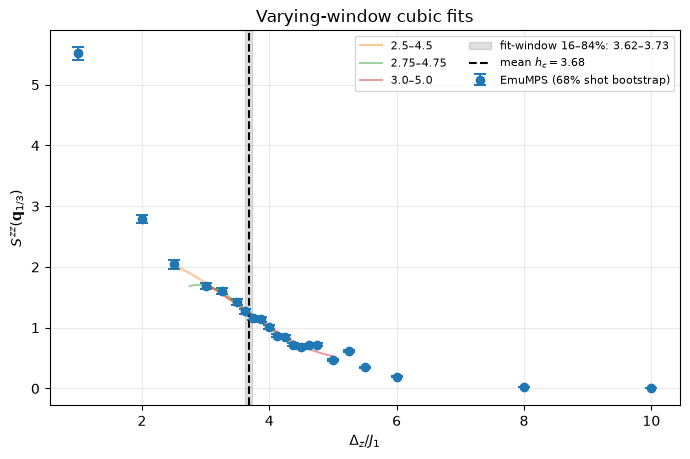

In [ ]:
FIT_WINDOWS=[(2.5,4.5),(2.75,4.75),(3.,5.),(3.25,5.25),(3.5,5.5),(3.75,5.75),(4.,6.)]
def one_window(x,y,lo,hi):
    m=(x>=lo)&(x<=hi)
    if m.sum()<5:return None
    coeff=np.polyfit(x[m],y[m],3);grid=np.linspace(lo,hi,2001);deriv=np.polyval(np.polyder(coeff),grid);k=np.argmin(deriv)
    xc=grid[k];margin=.03*(hi-lo)
    if xc<=lo+margin or xc>=hi-margin:return None
    return {'xc':xc,'coeff':coeff,'grid':grid,'fit':np.polyval(coeff,grid),'window':(lo,hi)}
fits=[one_window(fields,szz,*w) for w in FIT_WINDOWS];fits=[f for f in fits if f is not None]
if len(fits)<3:
    print('Not enough valid internal-slope fits. Add denser/wider field points before reporting a critical value.')
else:
    estimates=np.array([f['xc'] for f in fits]);central=estimates.mean();lo,hi=np.quantile(estimates,[.16,.84])
    print(f'window-variation estimate: {central:.3f} +{hi-central:.3f} -{central-lo:.3f}')
    fig,ax=plt.subplots(figsize=(7,4.7));ax.errorbar(fields,szz,yerr=szzerr,fmt='o',capsize=4,capthick=1.4,elinewidth=1.4,label='EmuMPS (68% shot bootstrap)')
    for f in fits:ax.plot(f['grid'],f['fit'],alpha=.45,label=f'{f["window"][0]}–{f["window"][1]}')
    ax.axvspan(lo,hi,color='black',alpha=.12,label=f'fit-window 16–84%: {lo:.2f}–{hi:.2f}')
    ax.axvline(central,ls='--',color='black',label=f'mean $h_c={central:.2f}$')
    ax.set(xlabel=r'$\Delta_z/J_1$',ylabel=r'$S^{zz}(\mathbf{q}_{1/3})$',title='Varying-window cubic fits');ax.grid(alpha=.25);ax.legend(ncol=2,fontsize=8);fig.tight_layout()

## 12. Interpretation and reporting checklist

Before reporting a critical value, verify: (1) $M^z$ and $S^{zz}$ change in the same field region; (2) $\chi=50$ and $100$ differences are small compared with the transition signal; (3) the slope extrema lie inside several windows; (4) the scan has enough points on both sides; and (5) statistical intervals are shown. Report this as an $N=49$, finite-time, central-25-site pseudo-critical estimate—not the thermodynamic critical point. Limitations include open boundaries, a one-layer rather than the paper's two-layer analysis buffer, global rather than site-resolved detuning offset, approximate $J_2/J_1$, finite pulse duration, MPS truncation, and shot noise.

## 13. Supplementary visualisation: bitstrings near the critical point

EmuMPS evolved all 49 atoms and returned a count dictionary for every scanned field. A key such as `001...` is one 49-site measurement configuration and its value is the number of times it occurred. Pulser preserves the register order used to construct `register`, so bit $i$ is plotted at `xy[i]`. We verify every bitstring has length $N=49$ before plotting.

We choose the available scan points nearest to $h_c-\Delta h$, $h_c$, and $h_c+\Delta h$, where $h=\Delta_z/J_1$. If the cubic-window analysis did not produce a reliable estimate, the code uses the sampled point with the most negative discrete slope only as a labelled visualisation fallback. This does not replace the critical-point fit.

For each selected field we show three reproducibly sampled raw shots. Sampling is weighted by the observed counts, so a bitstring measured ten times is ten times more likely to be selected than one measured once. The colours mean
$$0\rightarrow n_i=0\rightarrow z_i=+1,\qquad 1\rightarrow n_i=1\rightarrow z_i=-1.$$
Black borders identify the central $5\times5$ analysis region, although every displayed atom participated in the simulation. Individual panels are possible measurement outcomes, not pictures of the complete quantum state.

Finally, the mean map displays $\langle n_i\rangle=\sum_b C_b n_i(b)/\sum_b C_b$. Values near $0$ or $1$ indicate consistent outcomes; values near $1/2$ indicate strong shot-to-shot variation.

h_c used for visualisation = 3.676 (mean of valid cubic-window estimates)
available fields selected: [3.    3.625 4.375]


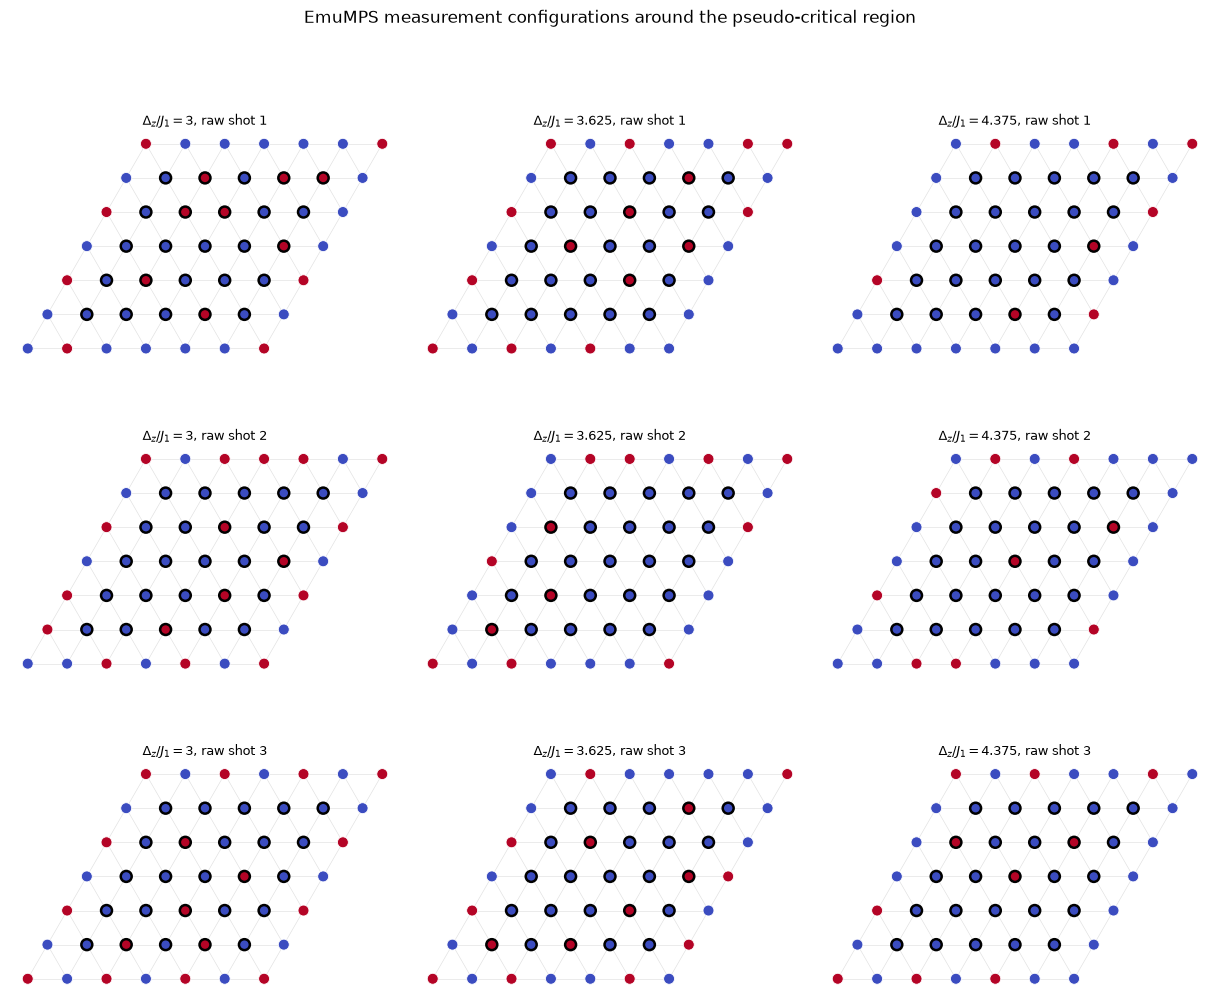

In [95]:
# Choose three already-computed fields around the pseudo-critical estimate.
if len(fits) >= 3:
    hc_visual = float(central)
    hc_source = 'mean of valid cubic-window estimates'
else:
    hc_visual = float(fields[np.argmin(np.gradient(szz, fields))])
    hc_source = 'fallback: sampled point of steepest discrete slope'

delta_h_visual = 0.75
targets = np.array([hc_visual-delta_h_visual, hc_visual, hc_visual+delta_h_visual])
visual_fields = np.array([fields[np.argmin(np.abs(fields-t))] for t in targets])
# Preserve order while removing a duplicate if coarse sampling maps two targets to one field.
visual_fields = np.array(list(dict.fromkeys(visual_fields)), dtype=float)
print(f'h_c used for visualisation = {hc_visual:.3f} ({hc_source})')
print('available fields selected:', visual_fields)

def validated_bitstrings(counts):
    bitstrings=np.array(list(counts), dtype=str)
    weights=np.array([counts[b] for b in bitstrings], dtype=float)
    if len(bitstrings)==0 or np.any(np.char.str_len(bitstrings)!=N):
        raise ValueError('Expected non-empty 49-bit EmuMPS results.')
    if np.any(weights<0) or weights.sum()<=0:
        raise ValueError('Bitstring counts must be non-negative with a positive total.')
    return bitstrings,weights/weights.sum()

def draw_configuration(ax,bitstring,title):
    bits=np.fromiter((int(x) for x in bitstring),dtype=np.int8,count=N)
    for i in range(N):
        for j in range(i+1,N):
            if np.isclose(r[i,j],spacing,rtol=1e-6):
                ax.plot(xy[[i,j],0],xy[[i,j],1],color='.88',lw=.45,zorder=0)
    edge=np.where(bulk_mask,'black','white')
    width=np.where(bulk_mask,1.8,.6)
    ax.scatter(xy[:,0],xy[:,1],c=bits,cmap='coolwarm',vmin=0,vmax=1,
               s=62,edgecolors=edge,linewidths=width,zorder=2)
    ax.set_title(title,fontsize=9);ax.set_aspect('equal');ax.axis('off')

visual_rng=np.random.default_rng(20260711)
n_raw_shots=3
fig,axes=plt.subplots(n_raw_shots,len(visual_fields),figsize=(4.1*len(visual_fields),3.5*n_raw_shots),squeeze=False)
for col,field in enumerate(visual_fields):
    strings,p=validated_bitstrings(counts50[field])
    chosen=visual_rng.choice(strings,size=n_raw_shots,replace=True,p=p)
    for row,b in enumerate(chosen):
        draw_configuration(axes[row,col],b,rf'$\Delta_z/J_1={field:g}$, raw shot {row+1}')
fig.suptitle('EmuMPS measurement configurations around the pseudo-critical region',y=1.01)
fig.tight_layout()

Text(0.5, 0.98, 'Shot-averaged occupation around the pseudo-critical region')

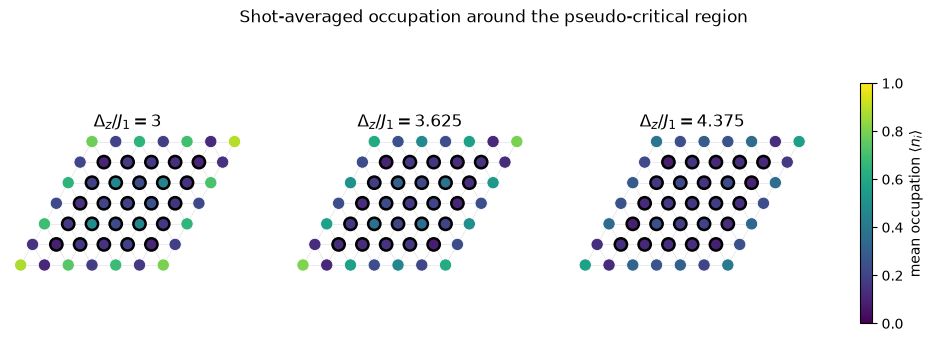

In [96]:
# Shot-averaged Rydberg occupation on every one of the 49 sites.
fig,axes=plt.subplots(1,len(visual_fields),figsize=(4.3*len(visual_fields),4),squeeze=False)
last_scatter=None
for ax,field in zip(axes[0],visual_fields):
    strings,p=validated_bitstrings(counts50[field])
    bit_array=np.array([[int(x) for x in b] for b in strings],dtype=float)
    mean_n=p@bit_array
    for i in range(N):
        for j in range(i+1,N):
            if np.isclose(r[i,j],spacing,rtol=1e-6):
                ax.plot(xy[[i,j],0],xy[[i,j],1],color='.88',lw=.45,zorder=0)
    edge=np.where(bulk_mask,'black','white');width=np.where(bulk_mask,1.8,.6)
    last_scatter=ax.scatter(xy[:,0],xy[:,1],c=mean_n,cmap='viridis',vmin=0,vmax=1,
                            s=78,edgecolors=edge,linewidths=width,zorder=2)
    ax.set_title(rf'$\Delta_z/J_1={field:g}$');ax.set_aspect('equal');ax.axis('off')
fig.colorbar(last_scatter,ax=axes.ravel().tolist(),label=r'mean occupation $\langle n_i\rangle$',shrink=.78)
fig.suptitle('Shot-averaged occupation around the pseudo-critical region',y=.98)